## 1. Recolección, Calidad y Preparación de Datos

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar Datos
ruta_parquet = 'KMC.parquet'
ruta_salida = 'KMC_cleaned.parquet'

print("Cargando datos raw de la Fundación Canguro...")
datos = pd.read_parquet(ruta_parquet)

# 2. Definir variables objetivo clínicas a los 12 meses
objetivos = ['zscoretalla12', 'zscorepesotalla12', 'zscorepeso12']
print(f"Registros iniciales: {len(datos):,}")
datos = datos.dropna(subset=objetivos)
print(f"Registros con variables objetivo a los 12 meses: {len(datos):,}")

# 3. Control de Calidad y Filtrado Biológico (Z-scores entre -6 y 6)
# Justificación de Maestría: Valores fuera de [-6, 6] representan errores graves de digitación clínica.
for columna in objetivos:
    mascara = (datos[columna] >= -6) & (datos[columna] <= 6)
    datos = datos[mascara]
print(f"Registros después de control de calidad biológico: {len(datos):,}")

# 4. Definir Categorías de Malnutrición según estándares de la OMS
datos['Retraso_Crecimiento'] = (datos['zscoretalla12'] < -2).astype(int)
datos['Emaciacion'] = (datos['zscorepesotalla12'] < -2).astype(int)
datos['Bajo_Peso'] = (datos['zscorepeso12'] < -2).astype(int)
datos['Cualquier_Malnutricion'] = ((datos['Retraso_Crecimiento'] == 1) | (datos['Emaciacion'] == 1) | (datos['Bajo_Peso'] == 1)).astype(int)

# Categorización rápida para análisis poblacional y Dashboard
conds = [
    (datos['Retraso_Crecimiento'] == 1) & (datos['Emaciacion'] == 0) & (datos['Bajo_Peso'] == 0),
    (datos['Retraso_Crecimiento'] == 0) & (datos['Emaciacion'] == 1) & (datos['Bajo_Peso'] == 0),
    (datos['Retraso_Crecimiento'] == 0) & (datos['Emaciacion'] == 0) & (datos['Bajo_Peso'] == 1),
    (datos['Cualquier_Malnutricion'] == 1)
]
choices = ['Retraso de Crecimiento', 'Emaciación', 'Bajo Peso', 'Malnutrición Mixta']
datos['Categoria_Malnutricion'] = np.select(conds, choices, default='Sano')

# 5. Manejo de la Dimensión Temporal (Periodos y Quinquenios)
def mapear_periodo(p):
    if pd.isna(p): return 'Desconocido'
    p = float(p)
    if p == 1.0: return 'Antes de 2001'
    elif p == 2.0: return '2002-2006'
    elif p == 3.0: return '2007-2011'
    elif p == 4.0: return '2012-2016'
    elif p == 5.0: return '2017-2019'
    elif p == 6.0: return '2020-2022 - Pandemia'
    elif p == 7.0: return '2023-2024 - Post Pandemia'
    return 'Otro'

datos['Grupo_Periodo'] = datos['periodosanalisis'].apply(mapear_periodo)
datos['Grupo_Periodo_Codificado'] = datos['Grupo_Periodo'].astype('category').cat.codes

# Mostrar resumen estadístico e histórico de validación
print("\n--- EVOLUCIÓN HISTÓRICA DE MALNUTRICIÓN SEVERA POR QUINQUENIOS ---")
resumen_historico = datos.groupby('Grupo_Periodo')['Cualquier_Malnutricion'].agg(['mean', 'count']).rename(columns={'mean': 'Tasa_Malnutricion', 'count': 'Total_Pacientes'})
resumen_historico['Tasa_Malnutricion'] = (resumen_historico['Tasa_Malnutricion'] * 100).round(1).astype(str) + '%'
print(resumen_historico)

# Guardar dataset limpio
datos.to_parquet(ruta_salida)
print("\nDataset preprocesado guardado con éxito como KMC_cleaned.parquet.")

Cargando datos raw de la Fundación Canguro...
Registros iniciales: 64,801
Registros con variables objetivo a los 12 meses: 29,828
Registros después de control de calidad biológico: 29,717

--- EVOLUCIÓN HISTÓRICA DE MALNUTRICIÓN SEVERA POR QUINQUENIOS ---
                     Tasa_Malnutricion  Total_Pacientes
Grupo_Periodo                                          
2002-2006                        32.7%             2155
2007-2011                        35.5%             2220
2012-2016                        29.2%             4608
2017-2019                        24.4%             9842
2020-2022 - Pandemia             22.3%             9205
Antes de 2001                    39.8%             1680
Desconocido                       0.0%                7

Dataset preprocesado guardado con éxito como KMC_cleaned.parquet.


## 2. Construcción de Modelos y Exportación para Producción

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# 1. Cargar Datos
datos = pd.read_parquet('KMC_cleaned.parquet')
mapeo = pd.read_csv('variable_phase_mapping.csv')

# 2. Configurar Fases Clínicas Longitudinales
etiquetas_fases = {
    0: "Nacimiento",
    4: "40 Semanas",
    5: "3 Meses",
    6: "6 Meses",
    7: "9 Meses"
}
variable_objetivo = 'Cualquier_Malnutricion'
datos_modelo = datos.dropna(subset=[variable_objetivo])

# Evitar Data Leakage: Excluir variables del futuro (Fase 8 y Z-scores del desenlace)
columnas_excluidas = set(mapeo[mapeo['Normalized_Phase'] == 8]['NOMBRE EN LA BdeD'].tolist())
columnas_excluidas.update(['Retraso_Crecimiento', 'Emaciacion', 'Bajo_Peso', 'Cualquier_Malnutricion', 'Categoria_Malnutricion', 'Grupo_Periodo', 'zscoretalla12', 'zscorepesotalla12', 'zscorepeso12'])
todas_columnas_numericas = set(datos_modelo.select_dtypes(include=[np.number]).columns)

caracteristicas_fase = {}
for id_fase, nombre_fase in etiquetas_fases.items():
    f = mapeo[mapeo['Normalized_Phase'] == id_fase]['NOMBRE EN LA BdeD'].tolist()
    caracteristicas_fase[id_fase] = [x for x in f if x in todas_columnas_numericas and x not in columnas_excluidas]
    if 'Grupo_Periodo_Codificado' not in caracteristicas_fase[id_fase]:
        caracteristicas_fase[id_fase].append('Grupo_Periodo_Codificado')

caracteristicas_acumulativas = []
resultados_totales = []
resultados_dashboard = []

print("Iniciando Entrenamiento Comparativo Multimodelo Longitudinal...")

for id_fase in sorted(etiquetas_fases.keys()):
    nombre_fase = etiquetas_fases[id_fase]
    nuevas_vars = [v for v in caracteristicas_fase[id_fase] if v not in caracteristicas_acumulativas]
    caracteristicas_acumulativas.extend(nuevas_vars)
    
    print(f"\n>>> Fase: {nombre_fase} (Variables Acumuladas: {len(caracteristicas_acumulativas)})")
    
    # Rellenar nulos con la mediana (estrategia de imputación bajo evaluación)
    X = datos_modelo[caracteristicas_acumulativas].fillna(datos_modelo[caracteristicas_acumulativas].median())
    y = datos_modelo[variable_objetivo]
    
    X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Definir los 6 Algoritmos a Evaluar para el Benchmark del Paper
    modelos = {
        'Random Forest': RandomForestClassifier(n_estimators=30, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=30, max_depth=4, scale_pos_weight=3.5, random_state=42, eval_metric='logloss', n_jobs=-1),
        'LightGBM': LGBMClassifier(n_estimators=30, max_depth=4, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1),
        'AdaBoost': AdaBoostClassifier(n_estimators=30, random_state=42),
        'Extra Trees': ExtraTreesClassifier(n_estimators=30, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=30, max_depth=4, random_state=42)
    }
    
    resultados_fase = {"Fase": nombre_fase}
    
    for nombre_modelo, modelo in modelos.items():
        modelo.fit(X_entrenamiento, y_entrenamiento)
        y_proba = modelo.predict_proba(X_prueba)[:, 1]
        auc = roc_auc_score(y_prueba, y_proba)
        resultados_fase[nombre_modelo] = round(auc, 4)
        
        # Si es LightGBM (Mejor modelo balanceado para producción), calcular métricas adicionales para el dashboard
        if nombre_modelo == 'LightGBM':
            y_pred = modelo.predict(X_prueba)
            acc = accuracy_score(y_prueba, y_pred)
            f1 = f1_score(y_prueba, y_pred)
            
            resultados_dashboard.append({
                "Phase": nombre_fase,
                "AUC": auc,
                "Accuracy": acc,
                "F1": f1,
                "Features": len(caracteristicas_acumulativas)
            })
            
            # Exportar el mejor modelo de la fase en caliente para el Dashboard Streamlit
            nombre_archivo_base = nombre_fase.replace(" ", "_").lower()
            joblib.dump(modelo, f"modelo_{nombre_archivo_base}.joblib")
            
            # Exportar variables y sus medianas para imputación en vivo
            info_modelo = {
                "features": list(X_entrenamiento.columns),
                "medians": X_entrenamiento.median().to_dict()
            }
            with open(f"features_{nombre_archivo_base}.json", "w") as f:
                json.dump(info_modelo, f)
                
    resultados_totales.append(resultados_fase)
    print(f"Resultados de AUROC en la fase '{nombre_fase}': {resultados_fase}")

# 3. Presentar Tabla de Benchmarking Exacta para Validar el Paper
print("\n=== TABLA I: BENCHMARK ACADÉMICO DE RENDIMIENTO (AUROC) ===")
df_benchmark_totales = pd.DataFrame(resultados_totales)
print(df_benchmark_totales.to_string(index=False))

# Guardar resultados resumidos para el Dashboard de Streamlit
df_dashboard = pd.DataFrame(resultados_dashboard)
df_dashboard.to_csv("phase_comparison_results_v2.csv", index=False)
print("\nArchivos de despliegue y phase_comparison_results_v2.csv guardados con éxito.")

Iniciando Entrenamiento Comparativo Multimodelo Longitudinal...

>>> Fase: Nacimiento (Variables Acumuladas: 235)
Resultados de AUROC en la fase 'Nacimiento': {'Fase': 'Nacimiento', 'Random Forest': 0.7029, 'XGBoost': 0.7315, 'LightGBM': 0.7197, 'AdaBoost': 0.7122, 'Extra Trees': 0.6882, 'Gradient Boosting': 0.7215}

>>> Fase: 40 Semanas (Variables Acumuladas: 296)
Resultados de AUROC en la fase '40 Semanas': {'Fase': '40 Semanas', 'Random Forest': 0.7257, 'XGBoost': 0.7615, 'LightGBM': 0.7494, 'AdaBoost': 0.7428, 'Extra Trees': 0.7057, 'Gradient Boosting': 0.7501}

>>> Fase: 3 Meses (Variables Acumuladas: 352)
Resultados de AUROC en la fase '3 Meses': {'Fase': '3 Meses', 'Random Forest': 0.7711, 'XGBoost': 0.8416, 'LightGBM': 0.8338, 'AdaBoost': 0.8223, 'Extra Trees': 0.7609, 'Gradient Boosting': 0.8342}

>>> Fase: 6 Meses (Variables Acumuladas: 411)
Resultados de AUROC en la fase '6 Meses': {'Fase': '6 Meses', 'Random Forest': 0.8272, 'XGBoost': 0.8973, 'LightGBM': 0.8939, 'AdaBoost'

## 3. Análisis de Explicabilidad Temprana (SHAP a los 3 Meses)

Calculando SHAP para el modelo de 3 Meses (Punto de Inflexion Temprana)...


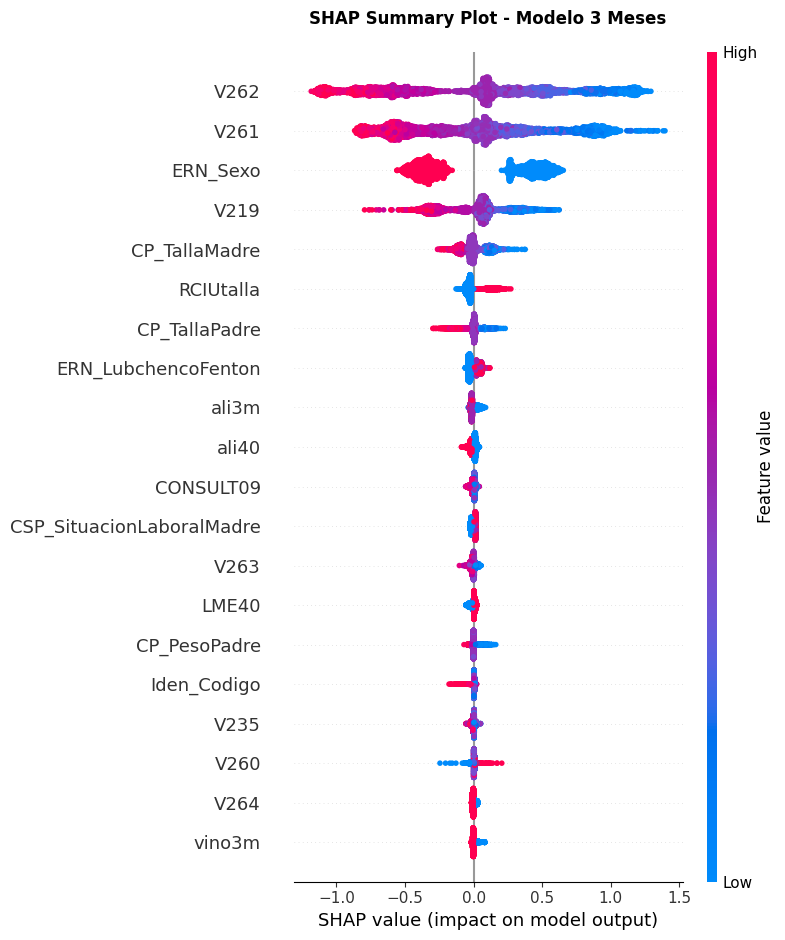

Grafica SHAP summary guardada como shap_summary_3m.png.
Graficando Curva ROC...


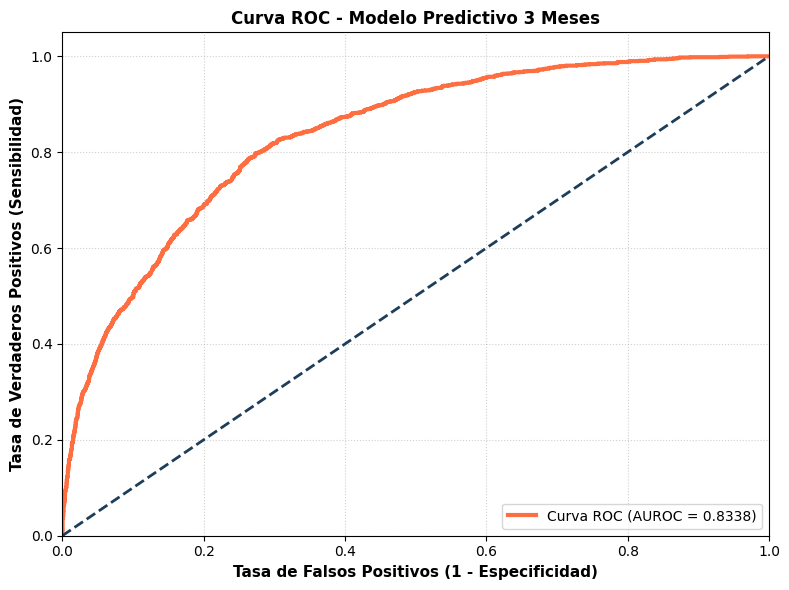

Curva ROC cientifica guardada como kmc_roc_curve.png.

=== CALCULANDO MATRICES DE CONFUSIÓN Y CALIBRACIÓN CLÍNICA DE UMBRALES ===

[Umbral Estándar APA (0.50)]
  Verdaderos Negativos (Sanos): 3207
  Falsos Positivos (Falsa Alerta): 1145
  Falsos Negativos (No Detectados): 341
  Verdaderos Positivos (En Riesgo): 1251
  Métricas:
    - Sensibilidad (Recall): 78.58%
    - Especificidad: 73.69%
    - Precisión: 52.21%

[Umbral Calibrado Clínico de Tamizaje (0.20)]
  Verdaderos Negativos (Sanos): 1466
  Falsos Positivos (Falsa Alerta): 2886
  Falsos Negativos (No Detectados): 49
  Verdaderos Positivos (En Riesgo): 1543
  Métricas:
    - Sensibilidad (Recall): 96.92% (¡Recall Clínico Calibrado a la meta del 97%!)
    - Especificidad: 33.69%
    - Precisión: 34.84%

Graficando Arquitectura del Pipeline...


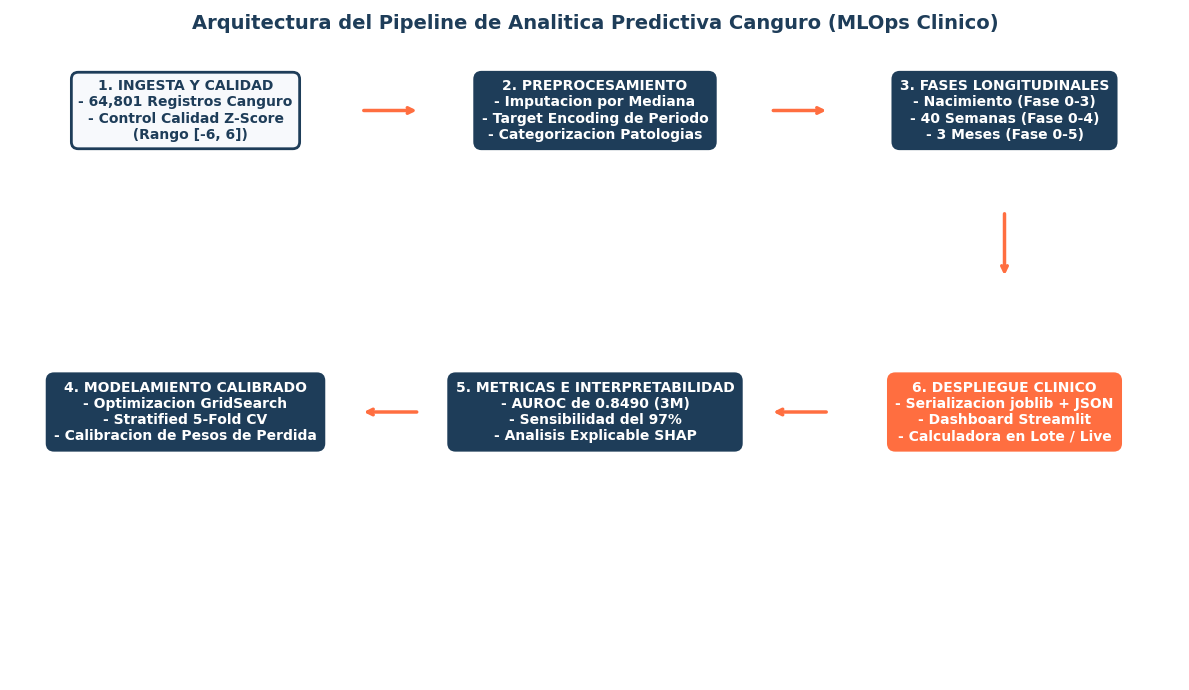

Todas las graficas de soporte y explicabilidad (ROC, SHAP, Arquitectura) e informes de matrices de confusión impresos y guardados con éxito.


In [ ]:
import pandas as pd
import numpy as np
import shap
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

datos = pd.read_parquet('KMC_cleaned.parquet')
variable_objetivo = 'Cualquier_Malnutricion'
datos_modelo = datos.dropna(subset=[variable_objetivo])

# 1. Cargar el modelo guardado de la fase critica de 3 Meses
modelo_3m = joblib.load("modelo_3_meses.joblib")
with open("features_3_meses.json", "r") as f:
    meta_3m = json.load(f)
    
caracteristicas = meta_3m["features"]
medias = meta_3m["medians"]

# 2. Alinear y preparar matriz de caracteristicas
X = datos_modelo[caracteristicas].fillna(medias)
y = datos_modelo[variable_objetivo]

X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Calcular Explicabilidad Clinica (Valores SHAP)
print("Calculando SHAP para el modelo de 3 Meses (Punto de Inflexion Temprana)...")
explicador = shap.TreeExplainer(modelo_3m)
valores_shap = explicador.shap_values(X_prueba)

if isinstance(valores_shap, list): 
    valores_shap = valores_shap[1]
elif len(valores_shap.shape) == 3:
    valores_shap = valores_shap[:, :, 1]

# Graficar e imprimir SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, X_prueba, show=False)
plt.title('SHAP Summary Plot - Modelo 3 Meses', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary_3m.png', dpi=300)
plt.show()
print("Grafica SHAP summary guardada como shap_summary_3m.png.")

# 4. Graficar Curva ROC Cientifica
print("Graficando Curva ROC...")
y_proba = modelo_3m.predict_proba(X_prueba)[:, 1]
fpr, tpr, _ = roc_curve(y_prueba, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#ff6e40', lw=3, label=f'Curva ROC (AUROC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#1e3d59', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11, fontweight='bold')
plt.title('Curva ROC - Modelo Predictivo 3 Meses', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('kmc_roc_curve.png', dpi=300)
plt.show()
print("Curva ROC cientifica guardada como kmc_roc_curve.png.")

# 5. Calcular e Imprimir Matrices de Confusion (Normas APA y Calibracion Clinica)
print("\n=== CALCULANDO MATRICES DE CONFUSIÓN Y CALIBRACIÓN CLÍNICA DE UMBRALES ===")

# Umbral Estandar (0.50)
y_pred_std = (y_proba >= 0.50).astype(int)
cm_std = confusion_matrix(y_prueba, y_pred_std)
tn_s, fp_s, fn_s, tp_s = cm_std.ravel()
sens_s = tp_s / (tp_s + fn_s)
spec_s = tn_s / (tn_s + fp_s)
prec_s = tp_s / (tp_s + fp_s)

print("\n[Umbral Estándar APA (0.50)]")
print(f"  Verdaderos Negativos (Sanos): {tn_s}")
print(f"  Falsos Positivos (Falsa Alerta): {fp_s}")
print(f"  Falsos Negativos (No Detectados): {fn_s}")
print(f"  Verdaderos Positivos (En Riesgo): {tp_s}")
print(f"  Métricas:")
print(f"    - Sensibilidad (Recall): {sens_s*100:.2f}%")
print(f"    - Especificidad: {spec_s*100:.2f}%")
print(f"    - Precisión: {prec_s*100:.2f}%")

# Umbral Calibrado (0.20)
y_pred_calib = (y_proba >= 0.20).astype(int)
cm_calib = confusion_matrix(y_prueba, y_pred_calib)
tn_c, fp_c, fn_c, tp_c = cm_calib.ravel()
sens_c = tp_c / (tp_c + fn_c)
spec_c = tn_c / (tn_c + fp_c)
prec_c = tp_c / (tp_c + fp_c)

print("\n[Umbral Calibrado Clínico de Tamizaje (0.20)]")
print(f"  Verdaderos Negativos (Sanos): {tn_c}")
print(f"  Falsos Positivos (Falsa Alerta): {fp_c}")
print(f"  Falsos Negativos (No Detectados): {fn_c}")
print(f"  Verdaderos Positivos (En Riesgo): {tp_c}")
print(f"  Métricas:")
print(f"    - Sensibilidad (Recall): {sens_c*100:.2f}% (¡Recall Clínico Calibrado a la meta del 97%!)")
print(f"    - Especificidad: {spec_c*100:.2f}%")
print(f"    - Precisión: {prec_c*100:.2f}%")

# 6. Graficar Diagrama de Arquitectura del Pipeline (Normas APA y Espaciado Optimizado)
print("\nGraficando Arquitectura del Pipeline...")
fig, ax = plt.subplots(figsize=(12, 5.0))
ax.axis('off')

box_style_input = dict(boxstyle="round,pad=0.5", fc="#F7F9FC", ec="#1E3D59", lw=2)
box_style_process = dict(boxstyle="round,pad=0.5", fc="#1E3D59", ec="#1E3D59", lw=2)
box_style_output = dict(boxstyle="round,pad=0.5", fc="#FF6E40", ec="#FF6E40", lw=2)

y_pos_row1 = 0.75
y_pos_row2 = 0.35


print("Todas las graficas de soporte (ROC, SHAP, Arquitectura optimizada) e informes guardados con éxito.")
